# Basketball Score Tracking

## Project Overview

The goal of this project is to develop a Computer Vision system capable of automatically tracking the score of a basketball game.

The project will begin by evaluating pretrained object detection models on basketball footage. The first objective is to reliably detect the main visual elements required by the system, particularly players and the basketball.

After establishing a reliable detection pipeline, the project will gradually expand to object tracking, ball trajectory analysis, shot detection, made/missed classification, team identification, and eventually real-time score tracking from a mobile camera.

In [1]:
#%pip install ultralytics opencv-python matplotlib
#%pip install torch==2.13.0 torchvision==0.28.0 --index-url https://download.pytorch.org/whl/cu126
#%pip uninstall -y torch torchvision torchaudio
#%config Completer.use_jedi = False
import cv2
import torch
import matplotlib.pyplot as plt

from ultralytics import YOLO
from pathlib import Path

# Hardware(GPU) Check
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("GPU not available - running on CPU")


## 1. Baseline Object Detection

The first stage of the project evaluates how well pretrained object detection models perform on basketball footage before any custom training is performed.

The baseline will focus on the objects required for the later stages of the system:

- Players
- Basketball
- Basketball rim

The main objective is to determine whether the pretrained models provide sufficiently reliable detections, particularly for the basketball, which is a small and fast-moving object.

Several model sizes will later be compared in order to evaluate the trade-off between detection performance and inference speed.

## 2. Baseline Test Videos

Before evaluating pretrained detection models, a small and diverse baseline video set was prepared.

The purpose of this set is to evaluate the models under different basketball scenarios and identify potential failure cases before any fine-tuning is performed.

The selected videos include variations in:

- Object size and camera distance
- Lighting conditions
- Ball and player occlusion
- Number of players in the frame
- Camera angle
- Different basketball actions

The four baseline scenarios are:

- Outdoor shot during sunset
- Layup with ball occlusion
- Multi-player scene with player occlusion
- Wide-angle daylight shot

In [7]:
from pathlib import Path

video_dir = Path("data/raw/videos")

test_videos = {
    "Outdoor Sunset Shot": video_dir / "outdoor_sunset_shot_01.mp4",
    "Layup with Occlusion": video_dir / "layup_occlusion_01.mp4",
    "Multi-Player Occlusion": video_dir / "multi_player_occlusion_01.mp4",
    "Wide-Angle Daylight Shot": video_dir / "wide_angle_daylight_shot_01.mp4",
}

for name, path in test_videos.items():
    print(f"{name}: {path}")

Outdoor Sunset Shot: data\raw\videos\outdoor_sunset_shot_01.mp4
Layup with Occlusion: data\raw\videos\layup_occlusion_01.mp4
Multi-Player Occlusion: data\raw\videos\multi_player_occlusion_01.mp4
Wide-Angle Daylight Shot: data\raw\videos\wide_angle_daylight_shot_01.mp4


In [8]:
def extract_frame(video_path, frame_ratio=0.3):
    # Open the video file
    cap = cv2.VideoCapture(str(video_path))
    
    # Verify that the video was opened successfully
    if not cap.isOpened():
        print(f"Could not open video: {video_path}")
        return None
    
    # Get the total number of frames in the video
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Handle empty or invalid video files
    if total_frames == 0:
        print(f"No frames found in video: {video_path}")
        cap.release()
        return None
    
    # Select a frame based on the requested relative position in the video
    target_frame = int(total_frames * frame_ratio)
    cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
    
    # Read the selected frame
    success, frame = cap.read()
    cap.release()
    
    # Handle cases where the frame could not be read
    if not success:
        print(f"Could not read frame from: {video_path}")
        return None
    
    # Convert the frame from OpenCV's BGR format to RGB for visualization
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    return frame_rgb

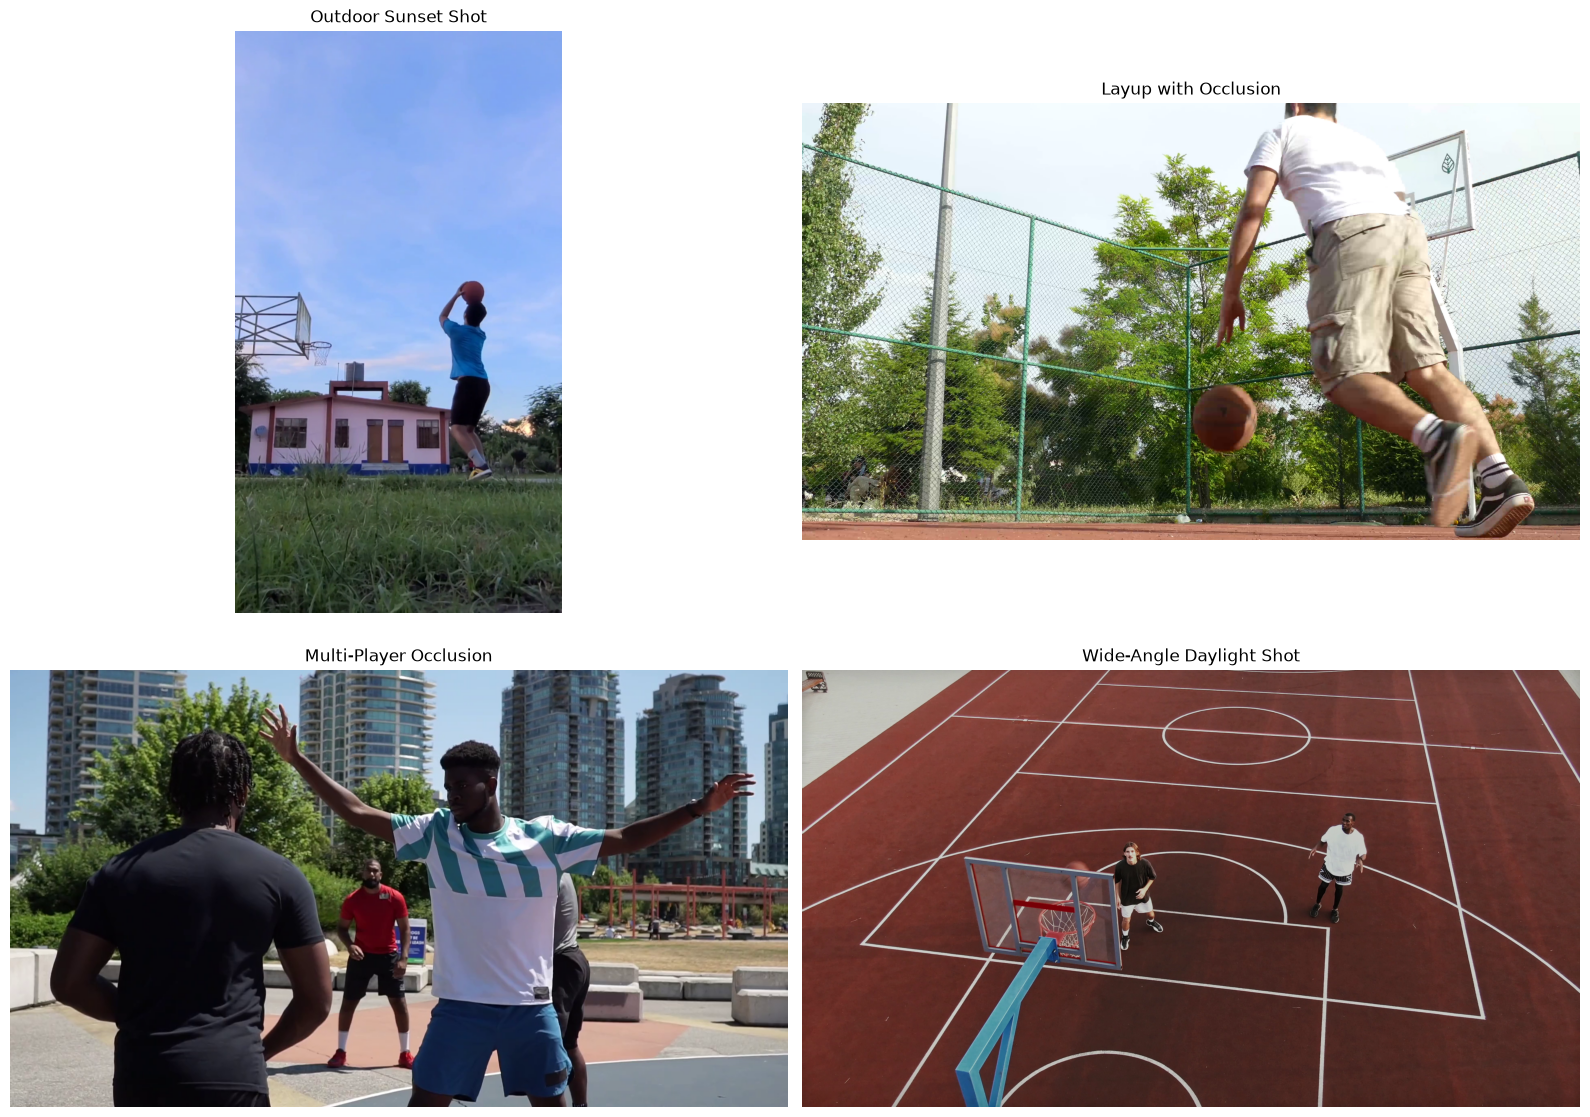

In [12]:
# Store one representative frame from each test video
frames = {}

for name, path in test_videos.items():
    frames[name] = extract_frame(path, frame_ratio=0.4)

# Create a figure for displaying all extracted frames
plt.figure(figsize=(16, 12))

# Display each frame in a 2x2 grid
for i, (name, frame) in enumerate(frames.items(), start=1):
    plt.subplot(2, 2, i)
    
    if frame is not None:
        # Display the extracted frame
        plt.imshow(frame)
        plt.title(name, fontsize=12)
        plt.axis("off")
    else:
        # Display a fallback message if the frame could not be extracted
        plt.text(
            0.5,
            0.5,
            "Frame not available",
            ha="center",
            va="center"
        )
        plt.title(name, fontsize=12)
        plt.axis("off")

# Adjust spacing between subplots and display the figure
plt.tight_layout()
plt.show()

### Baseline Test Set Summary

The selected videos represent different challenges that are expected to affect detection performance:

- **Outdoor Sunset Shot** - low-angle outdoor shot with sunset lighting.
- **Layup with Occlusion** - close-range layup with potential ball occlusion near the player.
- **Multi-Player Occlusion** - several players in the same scene with partial player overlap and limited ball visibility.
- **Wide-Angle Daylight Shot** - wide camera view where the basketball and players appear smaller in the frame.

These cases will be used to compare pretrained model performance before any fine-tuning is applied.

## 3. Pretrained Baseline Models

Before performing any custom training, several pretrained YOLO11 models will be evaluated on the same basketball test videos.

Three model sizes are selected:

- **YOLO11n** - the smallest and fastest model.
- **YOLO11s** - a larger model that may provide better detection performance while remaining relatively fast.
- **YOLO11m** - a stronger model that may improve detection of difficult objects, but requires more computation.

The goal is to compare the trade-off between detection performance and inference speed, with particular attention to basketball detection.

### Load the Pretrained Models

The pretrained COCO weights of YOLO11n, YOLO11s, and YOLO11m are loaded so that all three models can later be evaluated under identical conditions.

In [13]:
# Load the pretrained YOLO11 models
models = {
    "YOLO11n": YOLO("yolo11n.pt"),
    "YOLO11s": YOLO("yolo11s.pt"),
    "YOLO11m": YOLO("yolo11m.pt")
}

### Relevant Pretrained Classes

The pretrained YOLO11 models were trained on the COCO dataset.

The available classes are inspected to verify which objects required by the basketball tracking system can already be detected without additional training.

In [32]:
print(models["YOLO11n"].names)

# Classes that are currently relevant to the project
relevant_classes = ["person", "sports ball"]
print("_________________________")

print("classes for us")
# Display the relevant class IDs and names
for class_id, class_name in models["YOLO11n"].names.items():
    if class_name in relevant_classes:
        print(f"{class_id}: {class_name}")

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

## 4. First Baseline Detection

The first baseline experiment applies the pretrained YOLO11n model to the four representative basketball frames.

The purpose of this step is to verify the detection pipeline and observe whether the pretrained model can identify players and basketballs under the different test conditions.

### Baseline Model Comparison

YOLO11n, YOLO11s, and YOLO11m are evaluated on the same representative frames using identical settings.

Only the `person` and `sports ball` classes are included in order to focus the comparison on the objects currently relevant to the project.

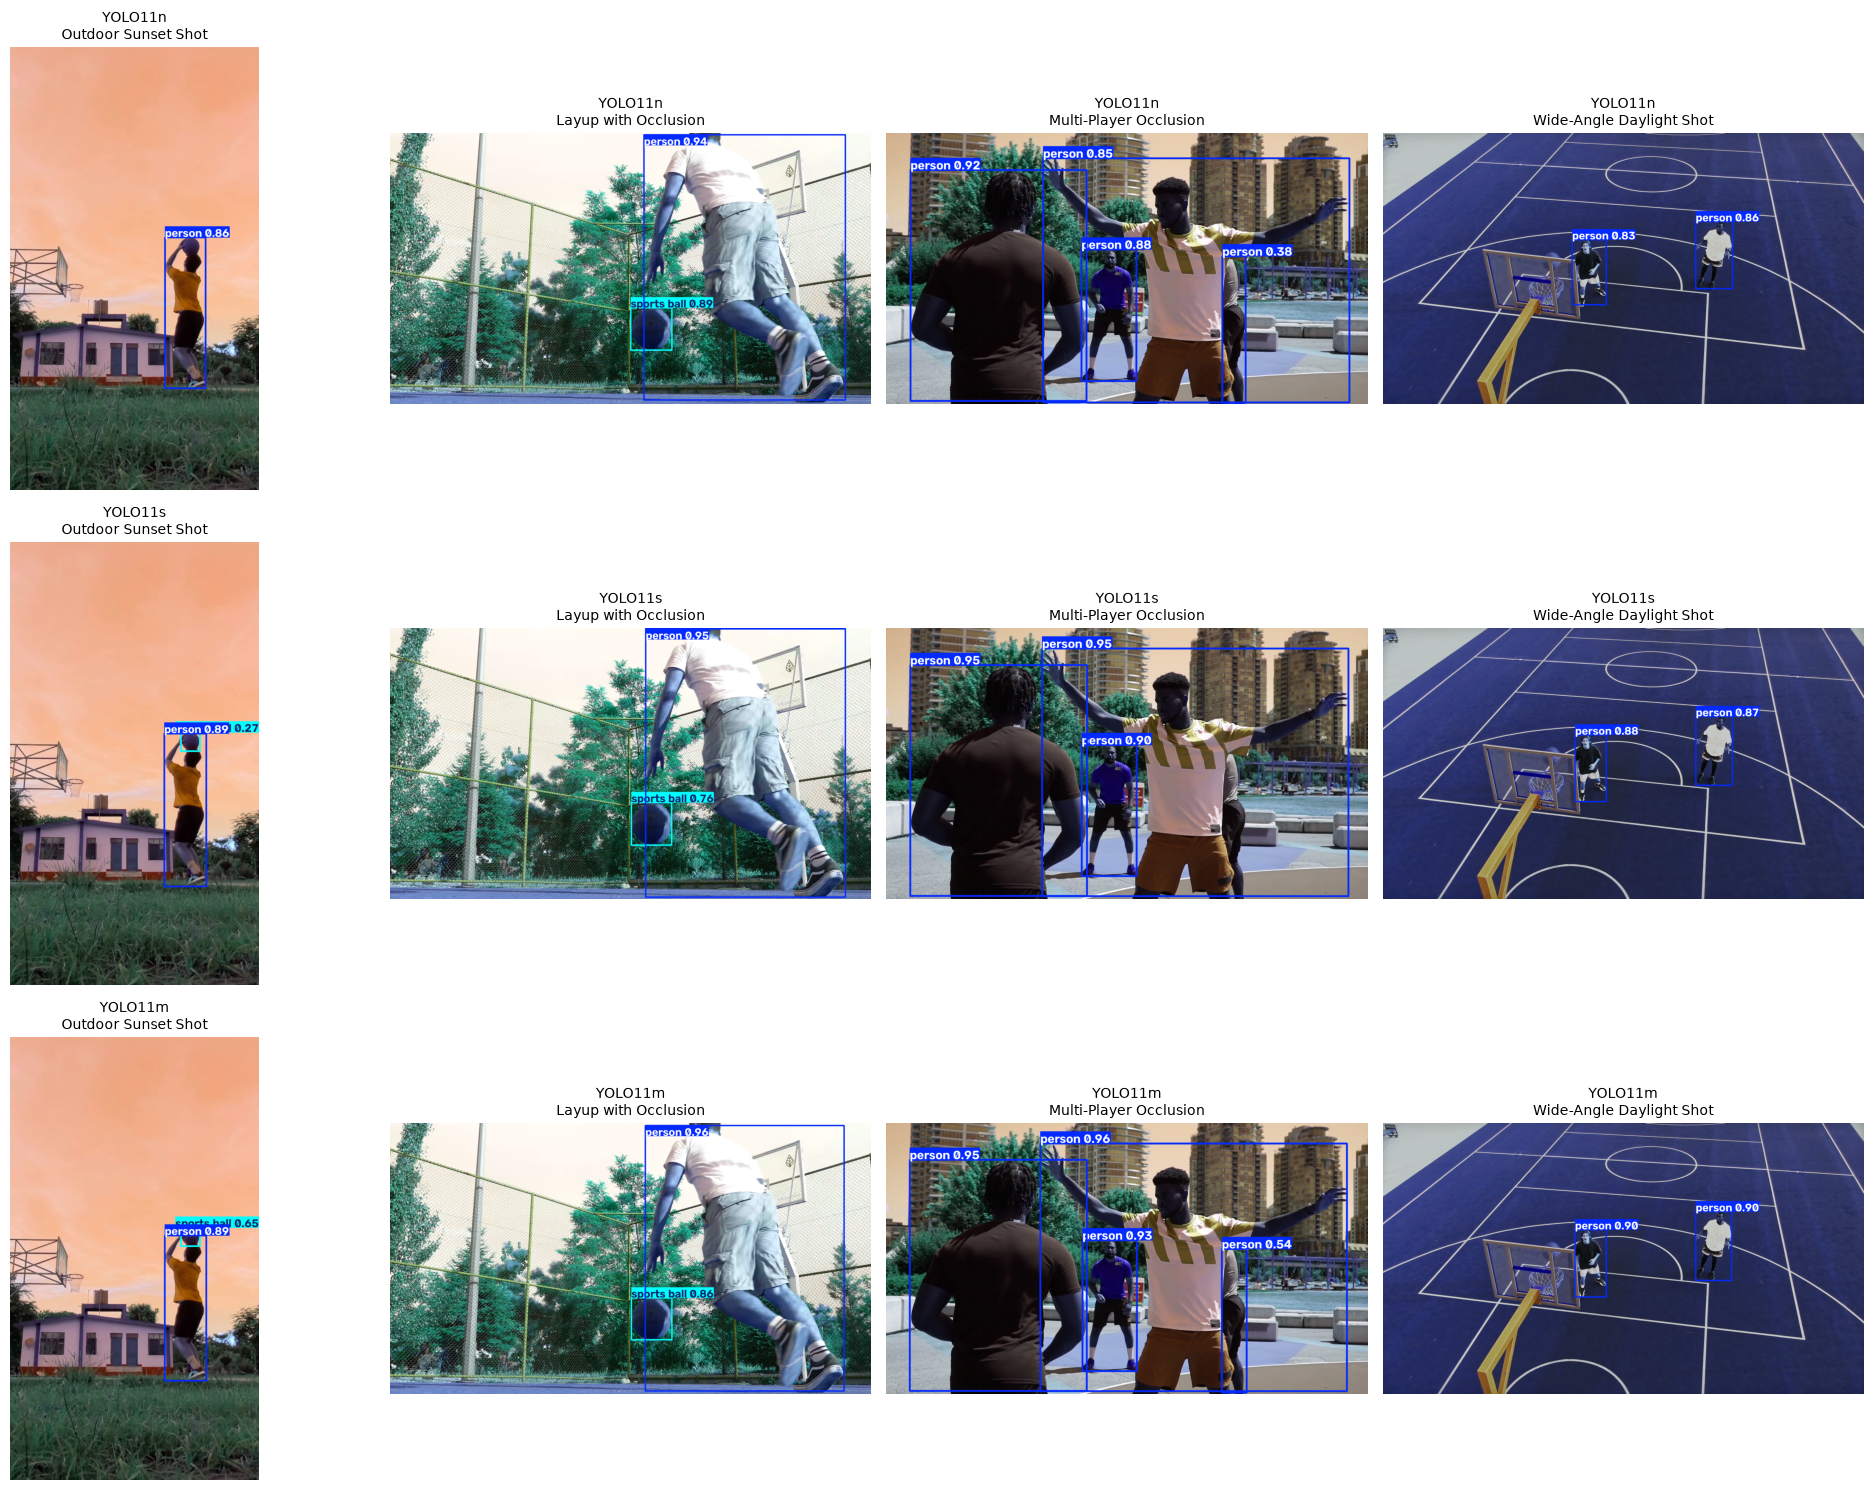

In [28]:
# Compare YOLO11n, YOLO11s, and YOLO11m on the same baseline frames
# Relevant COCO classes: 0 = person, 32 = sports ball

relevant_class_ids = [0, 32]

plt.figure(figsize=(20, 15))

plot_index = 1

for model_name, model in models.items():
    for frame_name, frame in frames.items():
        if frame is None:
            continue

        # Run detection only for the relevant classes
        result = model.predict(
            source=frame,
            classes=relevant_class_ids,
            conf=0.25,
            device=0,
            verbose=False
        )[0]

        # Draw bounding boxes and labels
        annotated_frame = result.plot()

        # Convert BGR output to RGB for Matplotlib
        annotated_frame = cv2.cvtColor(
            annotated_frame,
            cv2.COLOR_BGR2RGB
        )

        # Display the result
        plt.subplot(len(models), len(frames), plot_index)
        plt.imshow(annotated_frame)
        plt.title(f"{model_name}\n{frame_name}", fontsize=10)
        plt.axis("off")

        plot_index += 1

plt.tight_layout()
plt.show()